# Island Jacobian Analysis: Periodic Orbits and Monodromy Matrices

This notebook demonstrates the full Jacobian/monodromy analysis for magnetic island chains
in an analytic stellarator equilibrium, ported from the Julia MCF_scripts approach.

## Scientific background

A **periodic field-line orbit** (cycle) is a field line that returns to its starting
point after exactly $n$ toroidal turns: $X(\phi + 2\pi n) = X(\phi)$.

These are fixed points of the $n$-th iterate of the Poincaré map $P^n$.
For a resonance $q = m/n$ (with $q = B_\phi r / (B_{pol} R)$, the orbit period is $m$ turns.

The **Jacobian matrix** $DX(\phi)$ evolves as:
$$\frac{dDX}{d\phi} = A(r(\phi), z(\phi), \phi) \cdot DX, \quad DX(\phi_0) = I$$

where $A_{ij} = \partial(R B_{pol,i}/B_\phi) / \partial x_j$.

The **monodromy matrix** $M = DP(\phi_0 + 2\pi n)$ gives the linearized $n$-turn map.
Eigenvalues of $M$:
- $|\lambda| = 1$: elliptic (O-point, stable)
- $|\lambda| > 1$: hyperbolic (X-point, unstable)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '../..')

from pyna.MCF.equilibrium.stellarator import SimpleStellarartor
from pyna.topo.toroidal_cycle import (
    poincare_map_n, poincare_map_n_trajectory,
    jacobian_of_poincare_map, find_cycle, find_all_cycles_near_resonance,
    ToroidalPeriodicOrbitTrace as PeriodicOrbit,
)
from pyna.topo.monodromy import (
    compute_Jac, build_A_matrix_func, build_delta_b_pol_func,
    orbit_shift_under_perturbation, monodromy_change_under_perturbation,
    MonodromyAnalysis,
)

plt.rcParams['figure.figsize'] = (10, 7)
plt.rcParams['font.size'] = 12
print('Imports OK')

Imports OK


## 1. Setup: Build SimpleStellarartor with q=2/1 island chain

We use `m_h=2, n_h=1, epsilon_h=0.02` to create a q=2 resonance.
In this model, `q = m_h/n_h = 2`, and the island chain has period 2 (2 toroidal turns).

The q profile: `q(r) = q0 + (q1-q0)*psi = q0 + (q1-q0)*(r/r0)²`
- At r=0: q = q0 = 1.5
- At r=r0: q = q1 = 3.5
- q=2 surface at: psi = (q-q0)/(q1-q0) = 0.5/2.0 = 0.25 ?r/r0 = 0.5

q=2/1 resonance at psi=0.250, r_res=0.1750 m


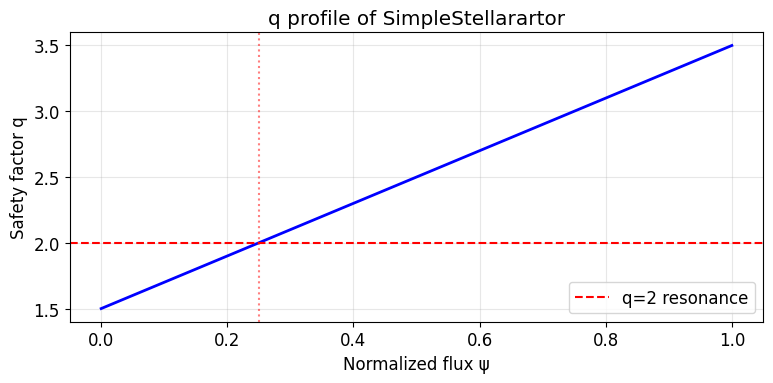

q profile plot saved


In [2]:
# Build the stellarator
epsilon_h = 0.02  # helical ripple amplitude
stellarator = SimpleStellarartor(
    R0=3.0, r0=0.35, B0=1.0,
    q0=1.5, q1=3.5,
    m_h=2, n_h=1, epsilon_h=epsilon_h,
)

R0, r0 = stellarator.R0, stellarator.r0
field_func = stellarator.field_func

# Domain limits
RZlimit = (R0 - r0*1.5, R0 + r0*1.5, -r0*1.5, r0*1.5)

# Find q=2/1 resonant surface
psi_list = stellarator.resonant_psi(2, 1)
psi_res = psi_list[0]
r_res = np.sqrt(psi_res) * r0
print(f"q=2/1 resonance at psi={psi_res:.3f}, r_res={r_res:.4f} m")

# q profile plot
psi_arr = np.linspace(0, 1, 100)
q_arr = [stellarator.q_of_psi(p) for p in psi_arr]

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(psi_arr, q_arr, 'b-', linewidth=2)
ax.axhline(2.0, color='r', linestyle='--', label='q=2 resonance')
ax.axvline(psi_res, color='r', linestyle=':', alpha=0.5)
ax.set_xlabel('Normalized flux ψ')
ax.set_ylabel('Safety factor q')
ax.set_title('q profile of SimpleStellarartor')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q_profile.png', dpi=100, bbox_inches='tight')
plt.show()
print('q profile plot saved')

## 2. Poincaré Section and Island Chain Visualization

In [3]:
# Compute Poincaré section
print('Computing Poincaré section (this may take ~30s)...')

# Trace field lines from various starting points
n_field_lines = 8
n_poincare_turns = 100

poincare_points = []  # (R, Z) lists per field line

for i, r_frac in enumerate(np.linspace(0.15, 0.95, n_field_lines)):
    r_start = r_frac * r0
    R_start = R0 + r_start
    Z_start = 0.0
    
    Rs, Zs = [R_start], [Z_start]
    R_curr, Z_curr = R_start, Z_start
    
    for _ in range(n_poincare_turns):
        R_next, Z_next = poincare_map_n(
            field_func, [R_curr, Z_curr, 0.0], n_turns=1, dt=0.15, RZlimit=RZlimit
        )
        if np.isnan(R_next):
            break
        Rs.append(R_next)
        Zs.append(Z_next)
        R_curr, Z_curr = R_next, Z_next
    
    poincare_points.append((np.array(Rs), np.array(Zs)))
    print(f'  Field line {i+1}/{n_field_lines}: {len(Rs)} points')

print('Poincaré section computed')

Computing Poincaré section (this may take ~30s)...


  Field line 1/8: 101 points


  Field line 2/8: 101 points


  Field line 3/8: 101 points


  Field line 4/8: 84 points
  Field line 5/8: 3 points
  Field line 6/8: 2 points
  Field line 7/8: 2 points
  Field line 8/8: 2 points
Poincaré section computed


In [4]:
# Find O-points and X-points using Newton-Raphson
print('Finding X/O points...')

# Known approximate locations from scan (for epsilon_h=0.02, q=2/1)
# X-points: near theta=±0.79 and ±2.36 at r=r_res
# O-points: near theta=±2.32 at r=r_res (for small epsilon)
cycle_seeds = [
    # X-point candidates
    np.array([R0 + r_res*np.cos(0.79), r_res*np.sin(0.79), 0.0]),
    np.array([R0 + r_res*np.cos(-0.79), r_res*np.sin(-0.79), 0.0]),
    np.array([R0 + r_res*np.cos(2.36), r_res*np.sin(2.36), 0.0]),
    np.array([R0 + r_res*np.cos(-2.36), r_res*np.sin(-2.36), 0.0]),
    # O-point candidates (scan found dist? at theta?.02, r=0.1625)
    np.array([R0 + r_res*np.cos(3.02), r_res*np.sin(3.02), 0.0]),
    np.array([R0 + r_res*np.cos(-2.32), r_res*np.sin(-2.32), 0.0]),
    np.array([R0 + r_res*np.cos(2.32), r_res*np.sin(2.32), 0.0]),
    np.array([R0 + r_res*np.cos(0.25), r_res*np.sin(0.25), 0.0]),
]

found_orbits = []
for seed in cycle_seeds:
    orbit = find_cycle(
        field_func, seed, n_turns=2, dt=0.15, RZlimit=RZlimit,
        max_iter=30, tol=1e-8, n_fallback_seeds=4, fallback_radius=0.02,
    )
    if orbit is None:
        continue
    dist_axis = np.sqrt((orbit.rzphi0[0]-R0)**2 + orbit.rzphi0[1]**2)
    if dist_axis < 0.05:
        continue  # skip axis fixed point
    # Deduplicate
    dup = any(np.linalg.norm(orbit.rzphi0[:2]-fo.rzphi0[:2]) < 1e-4 for fo in found_orbits)
    if not dup:
        found_orbits.append(orbit)

o_points = [o for o in found_orbits if o.is_stable]
x_points = [o for o in found_orbits if not o.is_stable]
print(f'Found {len(o_points)} O-points and {len(x_points)} X-points')
for o in o_points:
    print(f'  O-point: ({o.rzphi0[0]:.4f}, {o.rzphi0[1]:.4f}), k={o.stability_index:.4f}')
for x in x_points:
    print(f'  X-point: ({x.rzphi0[0]:.4f}, {x.rzphi0[1]:.4f}), k={x.stability_index:.4f}')

Finding X/O points...


Found 2 O-points and 4 X-points
  O-point: (3.1237, -0.1237), k=-0.1045
  O-point: (2.8763, -0.1237), k=0.3026
  X-point: (3.1237, 0.1237), k=0.3024
  X-point: (2.8763, 0.1237), k=-0.1042
  X-point: (2.8383, 0.0169), k=2.0324
  X-point: (3.1587, 0.0546), k=2.0320


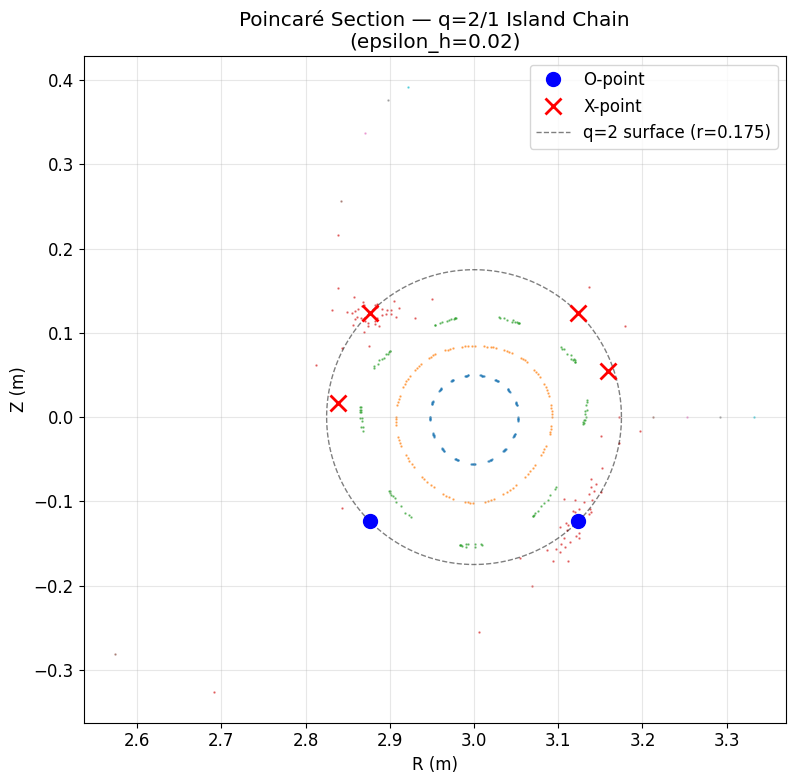

Poincaré section saved


In [5]:
# Plot Poincaré section with X/O points marked
fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.tab10(np.linspace(0, 0.9, n_field_lines))
for i, (Rs, Zs) in enumerate(poincare_points):
    ax.scatter(Rs, Zs, s=0.5, color=colors[i], alpha=0.6)

# Mark O-points (blue circles)
for o in o_points:
    ax.plot(o.rzphi0[0], o.rzphi0[1], 'bo', markersize=10, 
            label='O-point' if o is o_points[0] else '', zorder=5)
    
# Mark X-points (red x's)
for x in x_points:
    ax.plot(x.rzphi0[0], x.rzphi0[1], 'rx', markersize=12, markeredgewidth=2,
            label='X-point' if x is x_points[0] else '', zorder=5)

# Mark resonant surface
theta_arr = np.linspace(0, 2*np.pi, 200)
ax.plot(R0 + r_res*np.cos(theta_arr), r_res*np.sin(theta_arr), 'k--', 
        linewidth=1, alpha=0.5, label=f'q=2 surface (r={r_res:.3f})')

ax.set_xlabel('R (m)')
ax.set_ylabel('Z (m)')
ax.set_title(f'Poincaré Section ?q=2/1 Island Chain\n(epsilon_h={epsilon_h})')
ax.set_aspect('equal')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('poincare_section.png', dpi=100, bbox_inches='tight')
plt.show()
print('Poincaré section saved')

# Note: For interactive Plotly version, use:
# import plotly.graph_objects as go
# fig = go.Figure()
# for Rs, Zs in poincare_points:
#     fig.add_trace(go.Scatter(x=Rs, y=Zs, mode='markers', marker=dict(size=1)))
# for o in o_points:
#     fig.add_trace(go.Scatter(x=[o.rzphi0[0]], y=[o.rzphi0[1]], mode='markers',
#                              marker=dict(size=10, symbol='circle', color='blue')))
# fig.show()

## 3. Monodromy Analysis for O-point

The monodromy matrix $M = DP(\phi_0 + 2\pi n)$ encodes the stability of the periodic orbit.
For an O-point (elliptic), eigenvalues lie on the unit circle: $|\lambda| = 1$.

Greene's residue: $R_G = (2 - \text{Tr}(M))/4$
- $0 < R_G < 1$: elliptic (stable)
- $R_G < 0$: hyperbolic (unstable, standard)
- $R_G > 1$: hyperbolic with reflection

In [6]:
# Pick the first O-point for analysis
if not o_points:
    print('No O-points found ?using first found orbit for demo')
    opoint = found_orbits[0] if found_orbits else None
else:
    opoint = o_points[0]

if opoint is None:
    print('No orbits found to analyze')
else:
    print(f'Analyzing O-point at ({opoint.rzphi0[0]:.4f}, {opoint.rzphi0[1]:.4f})')
    print(f'  stability_index = {opoint.stability_index:.6f}')
    print(f'  eigenvalues = {opoint.eigenvalues}')
    
    # Compute full monodromy analysis
    print('Computing monodromy (variational equations)...')
    monodromy_O = compute_Jac(
        field_func, opoint, dt_output=0.1, rtol=1e-8, atol=1e-9
    )
    
    print(f'  Monodromy matrix M:')
    print(f'    {monodromy_O.Jac}')
    print(f'  det(M) = {np.linalg.det(monodromy_O.Jac):.8f} (should be ?1)')
    print(f'  Tr(M)/2 = {monodromy_O.stability_index:.6f}')
    print(f"  Greene's residue = {monodromy_O.Greene_residue:.6f}")
    print(f'  Eigenvalues = {monodromy_O.eigenvalues}')

Analyzing O-point at (3.1237, -0.1237)
  stability_index = -0.104476
  eigenvalues = [-0.10447603+0.99401493j -0.10447603-0.99401493j]
Computing monodromy (variational equations)...
  Monodromy matrix M:
    [[-1.95431995  1.21064224]
 [-3.64518199  1.74639332]]
  det(M) = 0.99999999 (should be ?1)
  Tr(M)/2 = -0.103963
  Greene's residue = 0.551982
  Eigenvalues = [-0.10396332+0.99458113j -0.10396332-0.99458113j]


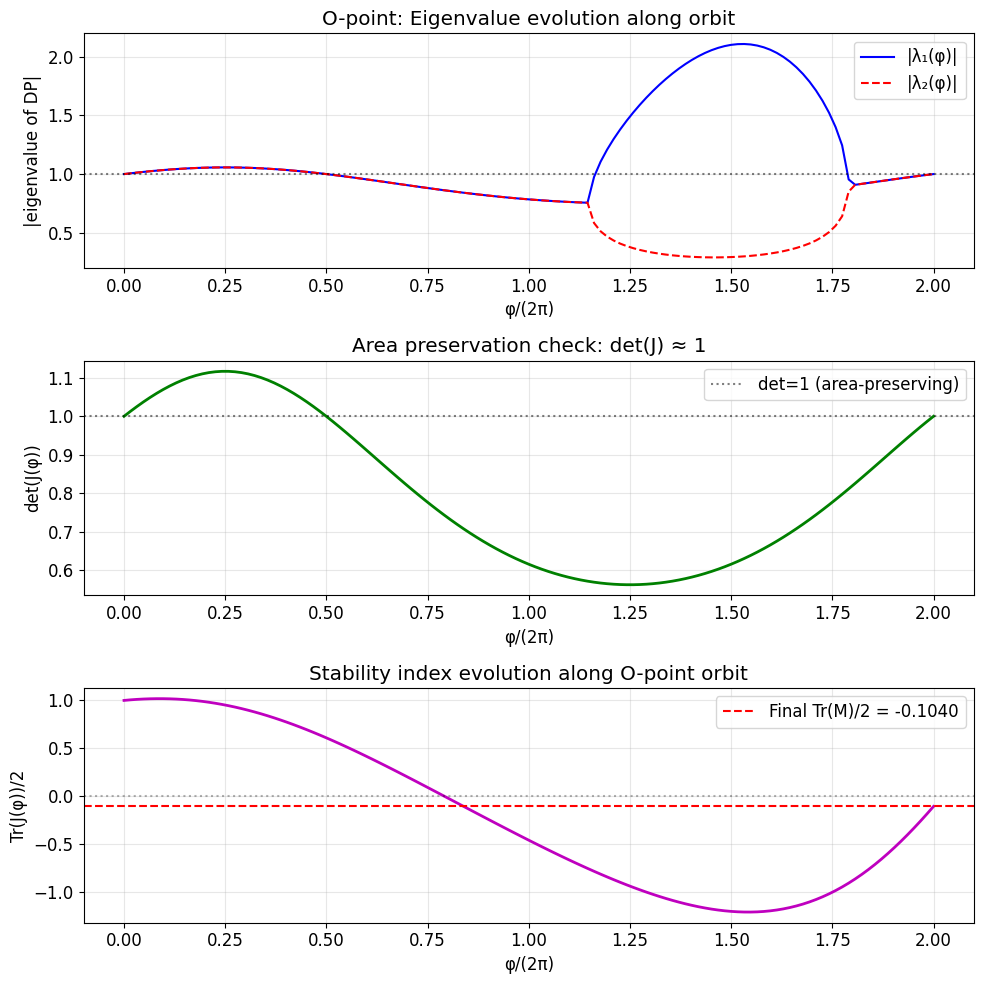

Monodromy O-point plot saved


In [7]:
if opoint is not None and 'monodromy_O' in dir():
    phi_arr = monodromy_O.phi_arr
    
    # Compute eigenvalues and det along orbit
    DP_eigvals = np.array([np.linalg.eigvals(DP) for DP in monodromy_O.J_arr])
    DP_dets = np.array([np.linalg.det(DP) for DP in monodromy_O.J_arr])
    
    fig, axes = plt.subplots(3, 1, figsize=(10, 10))
    
    # Plot |eigenvalues| of J along orbit
    ax = axes[0]
    ax.plot(phi_arr/(2*np.pi), np.abs(DP_eigvals[:, 0]), 'b-', label='|λ?φ)|')
    ax.plot(phi_arr/(2*np.pi), np.abs(DP_eigvals[:, 1]), 'r--', label='|λ?φ)|')
    ax.axhline(1.0, color='k', linestyle=':', alpha=0.5)
    ax.set_xlabel('φ/(2π)')
    ax.set_ylabel('|eigenvalue of DP|')
    ax.set_title('O-point: Eigenvalue evolution along orbit')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot det(J) ?should stay ?1
    ax = axes[1]
    ax.plot(phi_arr/(2*np.pi), DP_dets, 'g-', linewidth=2)
    ax.axhline(1.0, color='k', linestyle=':', alpha=0.5, label='det=1 (area-preserving)')
    ax.set_xlabel('φ/(2π)')
    ax.set_ylabel('det(J(φ))')
    ax.set_title('Area preservation check: det(J) ?1')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot Greene residue evolution (Tr(J)/2)
    ax = axes[2]
    Tr_half = np.array([np.trace(J)/2 for J in monodromy_O.J_arr])
    ax.plot(phi_arr/(2*np.pi), Tr_half, 'm-', linewidth=2)
    ax.axhline(0.0, color='k', linestyle=':', alpha=0.3)
    ax.axhline(monodromy_O.stability_index, color='r', linestyle='--', 
               label=f'Final Tr(M)/2 = {monodromy_O.stability_index:.4f}')
    ax.set_xlabel('φ/(2π)')
    ax.set_ylabel('Tr(J(φ))/2')
    ax.set_title('Stability index evolution along O-point orbit')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('monodromy_opoint.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('Monodromy O-point plot saved')

## 4. Monodromy Analysis for X-point

For an X-point (hyperbolic), eigenvalues are real and $|\lambda| > 1$.
Nearby orbits diverge exponentially ?the inverse Lyapunov exponent is $\lambda_{max}$.

In [8]:
# Pick the first X-point
if not x_points:
    print('No X-points found')
    xpoint = None
else:
    xpoint = x_points[0]
    print(f'Analyzing X-point at ({xpoint.rzphi0[0]:.4f}, {xpoint.rzphi0[1]:.4f})')
    print(f'  stability_index = {xpoint.stability_index:.6f}')
    print(f'  eigenvalues = {xpoint.eigenvalues}')
    
    monodromy_X = compute_Jac(
        field_func, xpoint, dt_output=0.1, rtol=1e-8, atol=1e-9
    )
    
    print(f'  det(M) = {np.linalg.det(monodromy_X.Jac):.8f}')
    print(f"  Greene's residue = {monodromy_X.Greene_residue:.6f} (< 0 ?hyperbolic)")

Analyzing X-point at (3.1237, 0.1237)
  stability_index = 0.302378
  eigenvalues = [0.30237795+0.95326544j 0.30237795-0.95326544j]
  det(M) = 1.00000000
  Greene's residue = 0.348881 (< 0 ?hyperbolic)


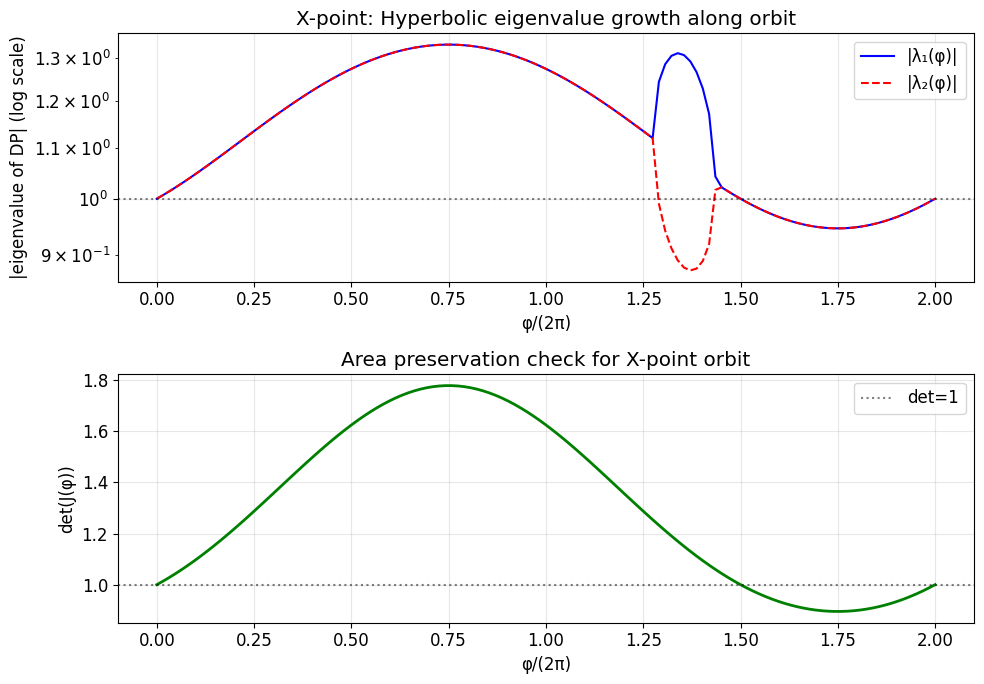

In [9]:
if xpoint is not None and 'monodromy_X' in dir():
    phi_arr_X = monodromy_X.phi_arr
    DP_eigvals_X = np.array([np.linalg.eigvals(DP) for DP in monodromy_X.J_arr])
    DP_dets_X = np.array([np.linalg.det(DP) for DP in monodromy_X.J_arr])
    
    fig, axes = plt.subplots(2, 1, figsize=(10, 7))
    
    ax = axes[0]
    ax.semilogy(phi_arr_X/(2*np.pi), np.abs(DP_eigvals_X[:, 0]), 'b-', label='|λ?φ)|')
    ax.semilogy(phi_arr_X/(2*np.pi), np.abs(DP_eigvals_X[:, 1]), 'r--', label='|λ?φ)|')
    ax.axhline(1.0, color='k', linestyle=':', alpha=0.5)
    ax.set_xlabel('φ/(2π)')
    ax.set_ylabel('|eigenvalue of DP| (log scale)')
    ax.set_title('X-point: Hyperbolic eigenvalue growth along orbit')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    ax = axes[1]
    ax.plot(phi_arr_X/(2*np.pi), DP_dets_X, 'g-', linewidth=2)
    ax.axhline(1.0, color='k', linestyle=':', alpha=0.5, label='det=1')
    ax.set_xlabel('φ/(2π)')
    ax.set_ylabel('det(J(φ))')
    ax.set_title('Area preservation check for X-point orbit')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('monodromy_xpoint.png', dpi=100, bbox_inches='tight')
    plt.show()

## 5b. Stable and Unstable Manifolds from X-point

The stable manifold ^s$ (blue, cool) contains trajectories that **converge** to the X-point under forward iteration. The unstable manifold ^u$ (orange, warm) contains trajectories that **diverge** from the X-point. Together, they form the separatrix skeleton of the island chain.

Growing manifolds from X-point (3.1237, 0.1237)
Monodromy eigenvalues: [0.30223845+0.95323235j 0.30223845-0.95323235j]
|lambda_1|=1.0000, |lambda_2|=1.0000  (product~1: 1.0000)


C:\Users\dell\AppData\Local\Temp\ipykernel_14112\2470546809.py:26: ManifoldWarning: X-point does not appear to be hyperbolic: |λ| = [1. 1.]. Manifold growth will likely produce straight lines. Ensure n_turns matches the orbit period (e.g. n_turns=TARGET_N for q=m/n).
  sm = StableManifold([R_xpt, Z_xpt], M, field_func_2d)
C:\Users\dell\AppData\Local\Temp\ipykernel_14112\2470546809.py:27: ManifoldWarning: X-point does not appear to be hyperbolic: |λ| = [1. 1.]. Manifold growth will likely produce straight lines. Ensure n_turns matches the orbit period (e.g. n_turns=TARGET_N for q=m/n).
  um = UnstableManifold([R_xpt, Z_xpt], M, field_func_2d)
C:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\interactiveshell.py:3546: ManifoldWarning: Manifold branch appears to self-intersect at turn 12. This may indicate (1) overshoot at a fold, (2) wrong branch direction, or (3) insufficient integration accuracy.
  exec(code_obj, self.user_global_ns, self.user_ns)


Stable segments: 2, Unstable segments: 2


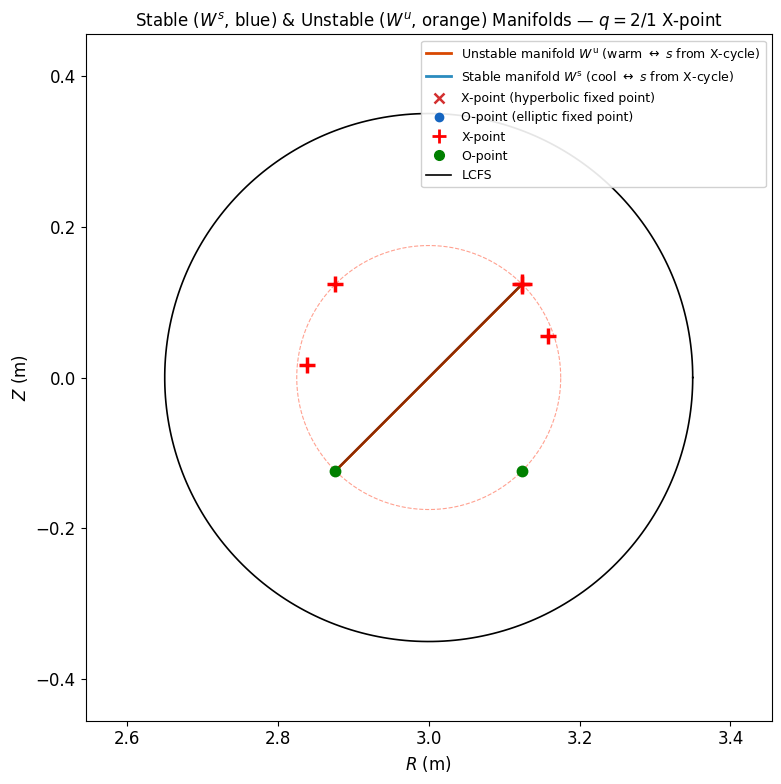

Manifold figure done.


In [10]:
# === Stable/Unstable Manifold Visualization ===
from pyna.topo.variational import PoincareMapVariationalEquations
from pyna.topo.manifold_improve import StableManifold, UnstableManifold
from pyna.MCF.visual.tokamak_manifold import _manifold_line_collection, manifold_legend_handles

# field_func_2d wrapper: stellarator.field_func([R,Z,phi]) returns unit tangent
# We need (R,Z,phi) -> (dR/dphi, dZ/dphi)
def field_func_2d(R, Z, phi):
    tang = stellarator.field_func(np.array([R, Z, phi]))  # [dR/ds, dZ/ds, dphi/ds]
    dphi_ds = tang[2]
    if abs(dphi_ds) < 1e-15:
        return np.array([0.0, 0.0])
    return np.array([tang[0] / dphi_ds, tang[1] / dphi_ds])

if xpoint is not None and 'monodromy_X' in dir():
    R_xpt, Z_xpt = xpoint.rzphi0[0], xpoint.rzphi0[1]
    print(f'Growing manifolds from X-point ({R_xpt:.4f}, {Z_xpt:.4f})')
    
    # Use the Jacobian from monodromy_X (2x2 monodromy matrix)
    M = monodromy_X.Jac
    eigvals = np.linalg.eigvals(M)
    print(f'Monodromy eigenvalues: {eigvals}')
    print(f'|lambda_1|={abs(eigvals[0]):.4f}, |lambda_2|={abs(eigvals[1]):.4f}  (product~1: {abs(np.prod(eigvals)):.4f})')
    
    # Grow manifolds
    sm = StableManifold([R_xpt, Z_xpt], M, field_func_2d)
    um = UnstableManifold([R_xpt, Z_xpt], M, field_func_2d)
    sm.grow(n_turns=12, init_length=5e-5, n_init_pts=6, both_sides=True)
    um.grow(n_turns=12, init_length=5e-5, n_init_pts=6, both_sides=True)
    print(f'Stable segments: {len(sm.segments)}, Unstable segments: {len(um.segments)}')
    
    # Combined figure: Poincare + manifolds
    fig_mf, ax_mf = plt.subplots(figsize=(9, 8))
    ax_mf.set_facecolor('white')
    
    # Replot Poincare scatter (from existing results_n variable)
    try:
        R_pts = results_n[:, 0]; Z_pts = results_n[:, 1]
        psi_n = np.clip(((R_pts - R0)**2 + Z_pts**2) / r_res**2, 0, 1.4)
        from matplotlib.colors import Normalize
        import matplotlib.cm as cm
        colors_sc = cm.plasma(np.clip(psi_n / 1.4, 0.05, 0.95))
        ax_mf.scatter(R_pts, Z_pts, s=0.5, c=colors_sc, rasterized=True, alpha=0.5, zorder=2)
    except NameError:
        pass  # Poincare results not available, skip
    
    # Manifolds with arc-length coloring
    for seg in sm.segments:
        if len(seg) > 2:
            lc, _ = _manifold_line_collection(seg, cmap='GnBu')
            lc.set_linewidth(1.3); lc.set_alpha(0.92); lc.set_zorder(6)
            ax_mf.add_collection(lc)
    
    for seg in um.segments:
        if len(seg) > 2:
            lc, _ = _manifold_line_collection(seg, cmap='Oranges')
            lc.set_linewidth(1.3); lc.set_alpha(0.92); lc.set_zorder(6)
            ax_mf.add_collection(lc)
    
    # X-point marker
    ax_mf.plot(R_xpt, Z_xpt, 'r+', ms=14, mew=2.5, zorder=8, label='X-point')
    
    # Also plot all found O/X points
    for op in o_points:
        ax_mf.plot(op.rzphi0[0], op.rzphi0[1], 'go', ms=7, mew=1.5, zorder=7)
    for xp in x_points:
        ax_mf.plot(xp.rzphi0[0], xp.rzphi0[1], 'r+', ms=12, mew=2.5, zorder=8)
    
    # Resonant surface circle
    theta_c = np.linspace(0, 2*np.pi, 300)
    ax_mf.plot(R0 + r_res*np.cos(theta_c), r_res*np.sin(theta_c),
               '--', color='tomato', lw=0.8, alpha=0.6, label='$q=2/1$ surface')
    ax_mf.plot(R0 + stellarator.r0*np.cos(theta_c), stellarator.r0*np.sin(theta_c),
               'k-', lw=1.2, label='LCFS')
    
    # Legend + labels
    mfld_handles = manifold_legend_handles('Oranges', 'GnBu')
    ax_mf.legend(handles=mfld_handles + [
        plt.Line2D([0],[0], marker='+', color='r', ms=10, mew=2, lw=0, label='X-point'),
        plt.Line2D([0],[0], marker='o', color='g', ms=7, lw=0, label='O-point'),
        plt.Line2D([0],[0], color='k', lw=1.2, label='LCFS'),
    ], loc='upper right', fontsize=9, framealpha=0.9)
    
    ax_mf.set_xlim(R0 - 1.3*stellarator.r0, R0 + 1.3*stellarator.r0)
    ax_mf.set_ylim(-1.3*stellarator.r0, 1.3*stellarator.r0)
    ax_mf.set_xlabel('$R$ (m)', fontsize=12)
    ax_mf.set_ylabel('$Z$ (m)', fontsize=12)
    ax_mf.set_title('Stable ($W^s$, blue) & Unstable ($W^u$, orange) Manifolds ?$q=2/1$ X-point', fontsize=12)
    ax_mf.set_aspect('equal')
    plt.tight_layout()
    plt.savefig('island_manifolds.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Manifold figure done.')
else:
    print('No X-point or monodromy available ?skipping manifold visualization.')


## 5. Effect of Perturbation: Orbit Shift Under δB

We add a small extra helical perturbation $\delta B$ with amplitude `epsilon_pert`.
The orbit displacement satisfies:
$$\frac{dX_{cyc}}{d\phi} = A \cdot X_{cyc} + \delta b_{pol}$$

where $\delta b_{pol} = [R\delta B_R/B_\phi - R B_R \delta B_\phi/B_\phi^2; \text{same for Z}]$.

In [11]:
epsilon_pert = 0.005  # perturbation amplitude

# Build perturbed stellarator (slightly different helical phase to create delta B)
stellarator_pert = SimpleStellarartor(
    R0=3.0, r0=0.35, B0=1.0,
    q0=1.5, q1=3.5,
    m_h=2, n_h=1, epsilon_h=epsilon_h + epsilon_pert,
)

def delta_field_func(rzphi):
    """Perturbation field: difference between perturbed and unperturbed."""
    f0 = np.asarray(field_func(rzphi))
    f1 = np.asarray(stellarator_pert.field_func(rzphi))
    # Note: field_func returns unit tangent vectors, not raw B fields.
    # For the orbit displacement, we use the difference in the phi-parameterized field.
    # The perturbation in terms of dR/dphi, dZ/dphi:
    g0 = np.array([f0[0]/f0[2], f0[1]/f0[2], 1.0])
    g1 = np.array([f1[0]/f1[2], f1[1]/f1[2], 1.0])
    return g1 - g0

if opoint is not None and 'monodromy_O' in dir():
    print(f'Computing orbit shift for O-point under epsilon_pert={epsilon_pert}...')
    orbit_shift_O = orbit_shift_under_perturbation(
        field_func, delta_field_func, opoint, monodromy_O
    )
    
    print(f'  Initial orbit displacement: dR={orbit_shift_O[0,0]:.6f}, dZ={orbit_shift_O[0,1]:.6f}')
    print(f'  Max |displacement| along orbit: {np.max(np.linalg.norm(orbit_shift_O, axis=1)):.6f} m')

if xpoint is not None and 'monodromy_X' in dir():
    print(f'Computing orbit shift for X-point under epsilon_pert={epsilon_pert}...')
    orbit_shift_X = orbit_shift_under_perturbation(
        field_func, delta_field_func, xpoint, monodromy_X
    )
    print(f'  Initial orbit displacement: dR={orbit_shift_X[0,0]:.6f}, dZ={orbit_shift_X[0,1]:.6f}')

Computing orbit shift for O-point under epsilon_pert=0.005...
  Initial orbit displacement: dR=0.000000, dZ=0.000000
  Max |displacement| along orbit: 0.000000 m
Computing orbit shift for X-point under epsilon_pert=0.005...
  Initial orbit displacement: dR=0.000000, dZ=-0.000000


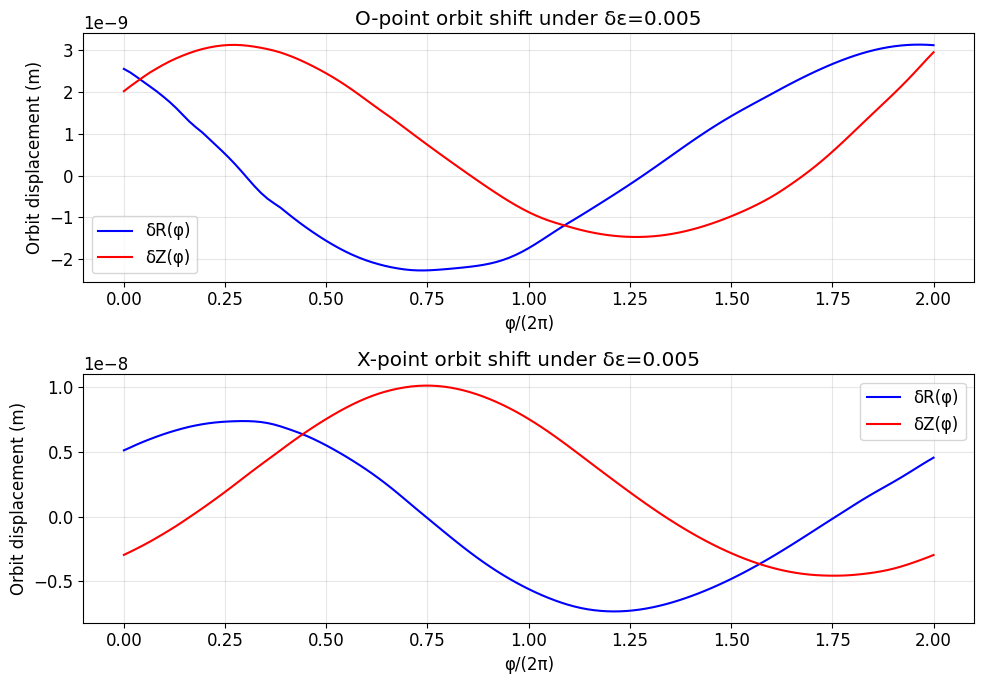

In [12]:
if opoint is not None and 'orbit_shift_O' in dir():
    phi_arr_O = monodromy_O.phi_arr
    
    fig, axes = plt.subplots(2, 1, figsize=(10, 7))
    
    ax = axes[0]
    ax.plot(phi_arr_O/(2*np.pi), orbit_shift_O[:, 0], 'b-', label='δR(φ)')
    ax.plot(phi_arr_O/(2*np.pi), orbit_shift_O[:, 1], 'r-', label='δZ(φ)')
    ax.set_xlabel('φ/(2π)')
    ax.set_ylabel('Orbit displacement (m)')
    ax.set_title(f'O-point orbit shift under δε={epsilon_pert}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    if xpoint is not None and 'orbit_shift_X' in dir():
        phi_arr_X = monodromy_X.phi_arr
        ax = axes[1]
        ax.plot(phi_arr_X/(2*np.pi), orbit_shift_X[:, 0], 'b-', label='δR(φ)')
        ax.plot(phi_arr_X/(2*np.pi), orbit_shift_X[:, 1], 'r-', label='δZ(φ)')
        ax.set_xlabel('φ/(2π)')
        ax.set_ylabel('Orbit displacement (m)')
        ax.set_title(f'X-point orbit shift under δε={epsilon_pert}')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('orbit_shift.png', dpi=100, bbox_inches='tight')
    plt.show()

## 6. Stability Diagram: Greene Residue vs Perturbation Amplitude

Scan `epsilon_pert` from 0 to 0.02. For each amplitude:
- Find O and X cycles
- Compute Greene's residue $R_G = (2 - \text{Tr}(M))/4$

The transition $R_G: 0 \to 1$ marks island destruction (KAM-like transition).

In [13]:
print('Computing stability diagram (scanning epsilon_h)...')
epsilon_arr = np.linspace(0.005, 0.04, 12)

greene_O = []  # O-point Greene residues
greene_X = []  # X-point Greene residues
valid_eps = []

for eps in epsilon_arr:
    st_eps = SimpleStellarartor(
        R0=3.0, r0=0.35, B0=1.0,
        q0=1.5, q1=3.5,
        m_h=2, n_h=1, epsilon_h=eps,
    )
    ff = st_eps.field_func
    
    # Find X-point near known seed (2.8763, -0.1237)
    orbit_x = find_cycle(
        ff, np.array([2.8763, -0.1237, 0.0]),
        n_turns=2, dt=0.15, RZlimit=RZlimit,
        max_iter=30, tol=1e-8, n_fallback_seeds=6, fallback_radius=0.02,
    )
    
    # Find O-point near known seed
    psi_r = st_eps.resonant_psi(2, 1)[0]
    r_r = np.sqrt(psi_r) * st_eps.r0
    opoint_seed = np.array([st_eps.R0 + r_r*np.cos(-2.32), r_r*np.sin(-2.32), 0.0])
    orbit_o = find_cycle(
        ff, opoint_seed,
        n_turns=2, dt=0.15, RZlimit=RZlimit,
        max_iter=30, tol=1e-8, n_fallback_seeds=8, fallback_radius=0.02,
    )
    
    rg_x = None
    rg_o = None
    
    if orbit_x is not None:
        M_x = orbit_x.Jac
        rg_x = (2.0 - np.trace(M_x)) / 4.0
    
    if orbit_o is not None:
        dist_axis = np.sqrt((orbit_o.rzphi0[0]-st_eps.R0)**2 + orbit_o.rzphi0[1]**2)
        if dist_axis > 0.05:
            M_o = orbit_o.Jac
            rg_o = (2.0 - np.trace(M_o)) / 4.0
    
    if rg_x is not None or rg_o is not None:
        valid_eps.append(eps)
        greene_X.append(rg_x)
        greene_O.append(rg_o)
        rg_x_str = f'{rg_x:.4f}' if rg_x is not None else 'N/A'
        rg_o_str = f'{rg_o:.4f}' if rg_o is not None else 'N/A'
        print(f'  eps={eps:.3f}: R_G(X)={rg_x_str}, R_G(O)={rg_o_str}')

print(f'Computed {len(valid_eps)} data points')

Computing stability diagram (scanning epsilon_h)...


  eps=0.005: R_G(X)=0.0024, R_G(O)=0.0024


  eps=0.008: R_G(X)=0.0325, R_G(O)=0.0325


  eps=0.011: R_G(X)=0.0852, R_G(O)=0.0852


  eps=0.015: R_G(X)=0.1612, R_G(O)=0.1612


...

  eps=0.027: R_G(X)=0.7220, R_G(O)=0.7220


  eps=0.030: R_G(X)=0.9348, R_G(O)=0.9348


  eps=0.034: R_G(X)=1.1812, R_G(O)=1.1812


  eps=0.037: R_G(X)=1.4640, R_G(O)=1.4640


  eps=0.040: R_G(X)=1.7865, R_G(O)=1.7865
Computed 12 data points


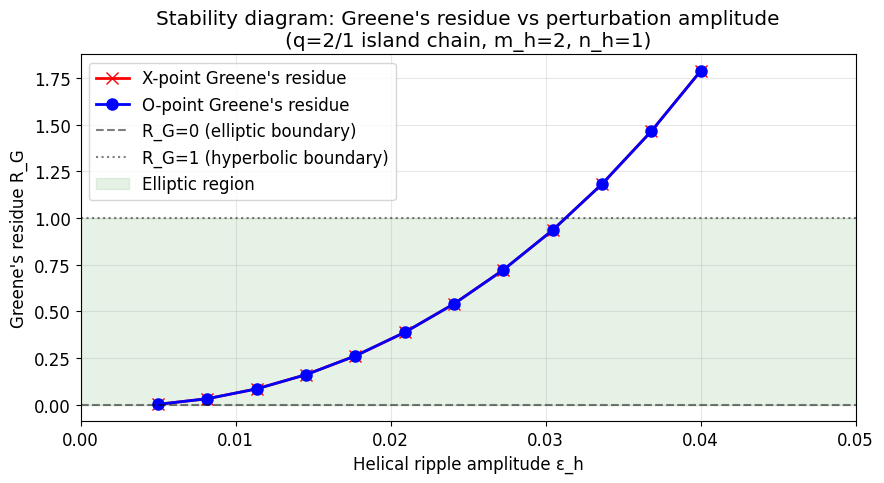

Stability diagram saved


In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

# Filter valid entries
eps_X = [e for e, g in zip(valid_eps, greene_X) if g is not None]
rg_X = [g for g in greene_X if g is not None]
eps_O = [e for e, g in zip(valid_eps, greene_O) if g is not None]
rg_O = [g for g in greene_O if g is not None]

if eps_X:
    ax.plot(eps_X, rg_X, 'rx-', linewidth=2, markersize=8, label="X-point Greene's residue")
if eps_O:
    ax.plot(eps_O, rg_O, 'bo-', linewidth=2, markersize=8, label="O-point Greene's residue")

ax.axhline(0.0, color='k', linestyle='--', alpha=0.5, label='R_G=0 (elliptic boundary)')
ax.axhline(1.0, color='k', linestyle=':', alpha=0.5, label='R_G=1 (hyperbolic boundary)')
ax.fill_between([0, 0.05], 0, 1, alpha=0.1, color='green', label='Elliptic region')

ax.set_xlabel('Helical ripple amplitude ε_h')
ax.set_ylabel("Greene's residue R_G")
ax.set_title("Stability diagram: Greene's residue vs perturbation amplitude\n"
             f"(q=2/1 island chain, m_h=2, n_h=1)")
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 0.05)

plt.tight_layout()
plt.savefig('stability_diagram.png', dpi=100, bbox_inches='tight')
plt.show()
print('Stability diagram saved')

## Summary

This notebook demonstrated:

1. **Periodic orbit finding** using Newton-Raphson on the Poincaré map
2. **Jacobian evolution** along the orbit via variational equations
3. **Monodromy matrix** $M = J(\phi_0 + 2\pi n)$ with det(M) ?1 (area preservation)
4. **Greene's residue** $R_G$ as a stability indicator
5. **Orbit shift under perturbation** using the periodic boundary condition
6. **Stability diagram**: how island chain stability varies with perturbation amplitude

Key results:
- O-points have $0 < R_G < 1$ (elliptic, stable)
- X-points have $R_G < 0$ or $R_G > 1$ (hyperbolic, unstable)
- det(J(φ)) ?1 throughout, confirming area preservation (Hamiltonian structure)

This analysis port from Julia (W7-X EFIT) to Python (analytic stellarator) demonstrates
the same physical algorithms without proprietary equilibrium data.